In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../semana_04/base_rh.csv", encoding="cp1252", sep=";", decimal=",")

df["Data_Admissao"] = pd.to_datetime(df["Data_Admissao"], format='%d/%m/%Y', dayfirst=True, errors='coerce')

print(df.head().to_string())

   ID_Funcionario                 Nome Departamento        Cargo   Salario Data_Admissao Genero  Idade Estado_Civil   Status
0               1          Julia Nunes    Logística  Coordenador   9088.34    2024-08-13      F     43     Solteiro  Inativo
1               2   Sr. Gustavo Duarte           TI      Gerente   8155.98    2017-04-29      F     59     Solteiro  Inativo
2               3  Srta. Mariana Cunha           RH  Coordenador  14027.93    2024-12-11      F     27   Divorciado    Ativo
3               4   Ana Sophia da Cruz     Produção      Técnico   6647.97    2019-06-16      M     50       Casado  Inativo
4               5    Dr. Nicolas Pinto     Produção      Gerente   8730.19    2019-03-29      F     62       Casado  Inativo


In [17]:
salario_np = df["Salario"].to_numpy()
idade_np = df["Idade"].to_numpy()

print(
    f"Shape do array de salários: {salario_np.shape[0]} linhas" 
      + (
      f" e {salario_np.shape[1]} colunas" if len(salario_np.shape) > 1 else " e 0 colunas"
    )
)
print(
    f"Shape do array de idades: {idade_np.shape[0]} linhas" 
      + (
      f" e {idade_np.shape[1]} colunas" if len(idade_np.shape) > 1 else " e 0 colunas"
    )
)

print(f"Tipo do array de salários: {salario_np.dtype}")
print(f"Tipo do array de idades: {idade_np.dtype}")
print(f"Maior salário: R$ {salario_np.max():,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Menor salário: R$ {salario_np.min():,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Média dos salários: R$ {salario_np.mean():,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Desvio padrão dos salários: R$ {salario_np.std():,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))
print(f"Maior idade: {idade_np.max()} anos")
print(f"Menor idade: {idade_np.min()} anos")
print(f"Média das idades: {idade_np.mean():.0f} anos")
print(f"Desvio padrão das idades: {idade_np.std():.0f} anos")

# Comparação com df.describe()
print("\nComparação com df.describe():\n")

def formatar_df(df):
    df_formatado = df.astype("object")
    for linha, coluna in df_formatado.stack().index:
        valor = df_formatado.loc[linha, coluna]
        if linha == "count":
            df_formatado.loc[linha, coluna] = f"{int(valor):,}".replace(",", ".")
        elif coluna == "Salario":
            df_formatado.loc[linha, coluna] = (
                f"R$ {valor:,.2f}"
                .replace(",", "X")
                .replace(".", ",")
                .replace("X", ".")
            )
        else:
            df_formatado.loc[linha, coluna] = f"{valor:.0f}"
    return df_formatado

desc = df[["Salario", "Idade"]].describe()

print(formatar_df(desc).to_string())
    

Shape do array de salários: 1000 linhas e 0 colunas
Shape do array de idades: 1000 linhas e 0 colunas
Tipo do array de salários: float64
Tipo do array de idades: int64
Maior salário: R$ 14.954,51
Menor salário: R$ 2.000,71
Média dos salários: R$ 8.579,95
Desvio padrão dos salários: R$ 3.655,54
Maior idade: 65 anos
Menor idade: 18 anos
Média das idades: 41 anos
Desvio padrão das idades: 14 anos

Comparação com df.describe():

            Salario  Idade
count         1.000  1.000
mean    R$ 8.579,95     41
std     R$ 3.657,37     14
min     R$ 2.000,71     18
25%     R$ 5.564,55     30
50%     R$ 8.571,13     41
75%    R$ 11.554,63     53
max    R$ 14.954,51     65


In [19]:
# Selecionar os 10 maiores salários usando pb.argsort
indices_maiores_salarios = np.argsort(salario_np)[-10:][::-1]
print("\n10 maiores salários:\n")
for indice in indices_maiores_salarios:
    print(f"R$ {salario_np[indice]:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."))


10 maiores salários:

R$ 14.954,51
R$ 14.951,53
R$ 14.948,18
R$ 14.942,48
R$ 14.942,39
R$ 14.923,61
R$ 14.918,19
R$ 14.914,63
R$ 14.912,48
R$ 14.904,99


In [30]:
# criar array para classificação de idades

condicoes = [
    (idade_np >= 60),
    (idade_np >= 44),
    (idade_np >=28),
]

geracao = ["Boomer", "Gen X", "Millennial"]

geracao_idade = np.select(condicoes, geracao, default="Gen Z")

In [31]:
# Usando máscara booleana para calcular o salário médio por geração
geracoes = np.unique(geracao_idade)

for gen in geracoes:
    mask = geracao_idade == gen
    media_salario = salario_np[mask].mean()
    print(f"Salário médio da geração {gen}: R$ {media_salario:,.2f}".replace(",", "Y").replace(".", ",").replace("Y", "."))

Salário médio da geração Boomer: R$ 8.223,51
Salário médio da geração Gen X: R$ 8.458,02
Salário médio da geração Gen Z: R$ 8.556,57
Salário médio da geração Millennial: R$ 8.814,86


In [35]:
# Criando o array `salario_normalizado` subtraindo a média e dividindo pelo desvio padrão (padronização z-score)

media_salario = salario_np.mean()
desvio_padrao_salario = salario_np.std()
salario_normalizado = (salario_np - media_salario) / desvio_padrao_salario

print(f"\nMédia após normalização: {salario_normalizado.mean():.6f}")
print(f"Desvio padrão após normalização: {salario_normalizado.std():.6f}")



Média após normalização: -0.000000
Desvio padrão após normalização: 1.000000


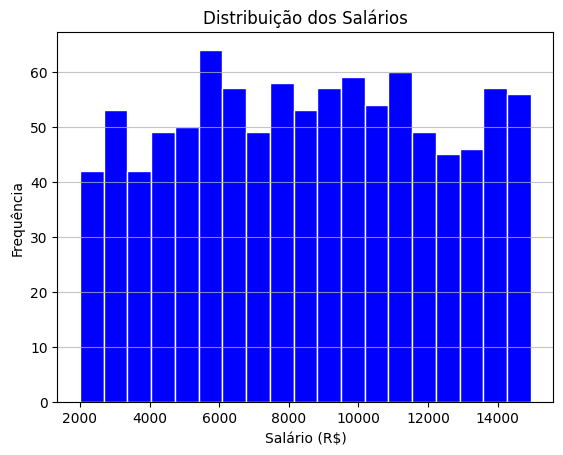

In [46]:
# criar um histograma dos salários usando matplotlib

plt.hist(salario_np, bins = np.linspace(salario_np.min(), salario_np.max(), 20), color='blue', edgecolor='white')
plt.title('Distribuição dos Salários')
plt.xlabel('Salário (R$)')
plt.ylabel('Frequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

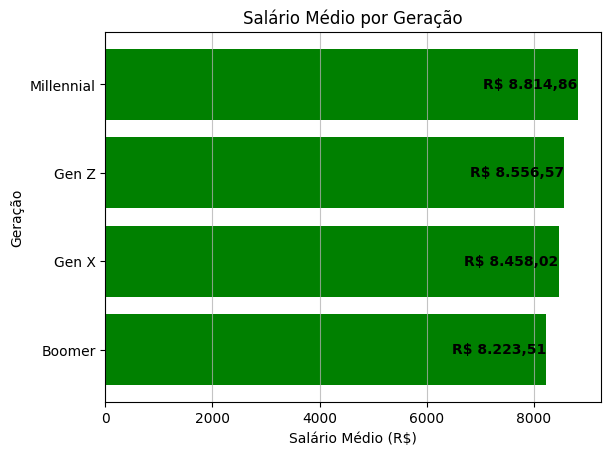

In [60]:
# criar grafico de barras horizontais de salario por geração

medias_gen = np.array([salario_np[geracao_idade == gen].mean() for gen in geracoes])

# colocar os valores em cada barra do gráfico de barras horizontais
for index, value in enumerate(medias_gen):
    plt.text(value, index, f"R$ {value:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."), va='center', ha='right', color='black', fontweight='bold')

plt.barh(geracoes, medias_gen, color='green')
plt.title('Salário Médio por Geração')
plt.xlabel('Salário Médio (R$)')
plt.ylabel('Geração')
plt.grid(axis='x', alpha=0.75)